In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Average speed per scenario

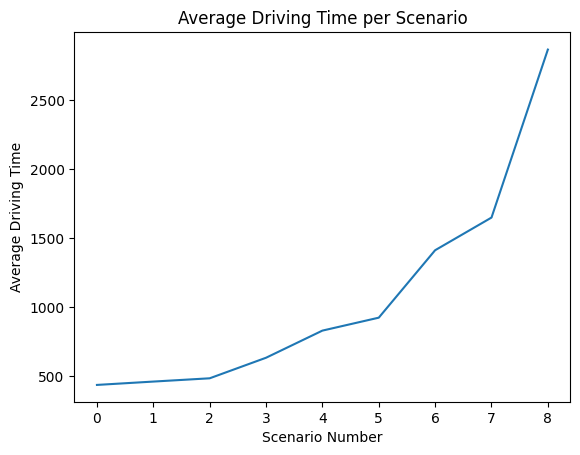

In [63]:
files = {}
for i in range(0, 9):
    files[i] = pd.read_csv(f'scenario{i}.csv')

scenario_numbers = []
means = []
lower_errors = []
upper_errors = []

for key in files:
    df = files[key]

    number = df["scenario"].iloc[0]
    mean = df["scenario_mean"].iloc[0]
    ci_lower = df["ci_95_lower"].iloc[0]
    ci_upper = df["ci_95_upper"].iloc[0]

    scenario_numbers.append(number)
    means.append(mean)
    lower_errors.append(mean - ci_lower)
    upper_errors.append(ci_upper - mean)

plt.figure()

plt.errorbar(
    scenario_numbers,
    means,
    yerr=[lower_errors, upper_errors],
)

plt.xlabel("Scenario Number")
plt.ylabel("Average Driving Time")
plt.title("Average Driving Time per Scenario")
plt.show()

In [71]:
summary_list = []

for key, df in files.items():
    mean = df["scenario_mean"].iloc[0]
    std = df["scenario_std"].iloc[0]
    n = len(df)
    min_val = df["average_driving_time"].min()
    max_val = df["average_driving_time"].max()
    se = std / (n ** 0.5) if n > 1 else 0
    cv = (std / mean * 100) if mean != 0 else 0

    summary_list.append({
        "Mean": mean,
        "Std Dev": std,
        "Min": min_val,
        "Max": max_val,
        "Std Error": se,
        "CV (%)": cv
    })

summary_df = pd.DataFrame(summary_list)
print(summary_df)

          Mean   Std Dev          Min          Max  Std Error    CV (%)
0   438.000000  0.000000   438.000000   438.000000   0.000000  0.000000
1   462.261041  1.346002   459.660489   464.337537   0.425643  0.291178
2   485.958484  1.115198   484.459077   487.505944   0.352657  0.229484
3   634.849816  2.731526   631.227790   639.094253   0.863784  0.430263
4   831.404511  3.522571   824.423409   837.283465   1.113935  0.423689
5   925.116672  5.768426   916.023962   934.693173   1.824136  0.623535
6  1413.630801  7.340849  1405.426117  1426.763319   2.321380  0.519290
7  1650.138809  4.212181  1643.785326  1657.415525   1.332009  0.255262
8  2866.938192  7.756329  2855.662428  2881.837806   2.452767  0.270544


# Top bridges

In [12]:
import pandas as pd

files = {}
for i in range(1, 9):
    files[i] = pd.read_csv(f"top10_bridges_scenario{i}.csv")

all_bridges = []

for scenario, df in files.items():
    df["scenario"] = scenario
    df = df.sort_values("mean_total_delay", ascending=False)
    df["rank"] = range(1, len(df) + 1)
    all_bridges.append(df)

# combine all scenarios
combined = pd.concat(all_bridges, ignore_index=True)

# keep only columns for appendix table
appendix_table = combined[["bridge_id", "scenario", "rank", "mean_total_delay"]]

# sort for readability
appendix_table = appendix_table.sort_values(["scenario", "rank"])

# round numbers
appendix_table["mean_total_delay"] = appendix_table["mean_total_delay"].round(2)

# rename columns for report
appendix_table = appendix_table.rename(columns={
    "bridge_id": "Bridge ID",
    "scenario": "Scenario",
    "rank": "Rank",
    "mean_total_delay": "Mean Total Delay"
})

# export to Excel for Word appendix
appendix_table.to_excel("appendix_bridge_ranking.xlsx", index=False)

print(appendix_table)

    Bridge ID  Scenario  Rank  Mean Total Delay
0         798         1     1           9534.69
1         643         1     2           4853.64
2        1018         1     3           4678.27
3        1000         1     4           2646.92
4        1090         1     5           2584.10
..        ...       ...   ...               ...
75       1018         8     6          56836.65
76         62         8     7          40324.59
77        617         8     8          33856.46
78        573         8     9          33729.65
79        606         8    10          33358.18

[80 rows x 4 columns]


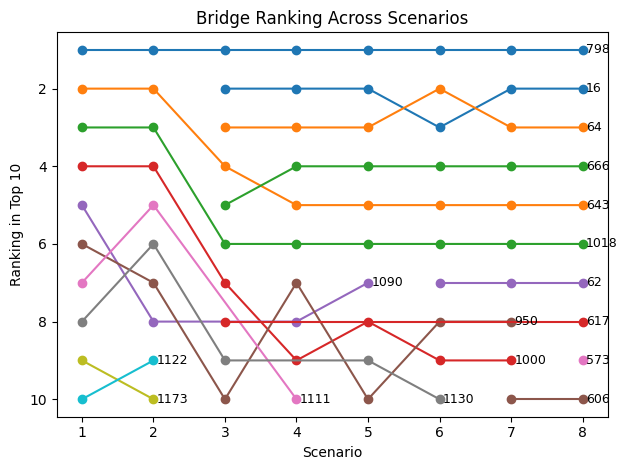

In [13]:
for bridge in unique_bridges:
    bridge_data = combined[combined["bridge_id"] == bridge]
    bridge_data = bridge_data.sort_values("scenario")

    plt.plot(
        bridge_data["scenario"],
        bridge_data["rank"],
        marker='o'
    )

    # Place bridge name at the last point
    last_scenario = bridge_data["scenario"].iloc[-1]
    last_rank = bridge_data["rank"].iloc[-1]
    plt.text(
        last_scenario + 0.05,  # slightly offset to the right
        last_rank,
        str(bridge),
        verticalalignment='center',
        fontsize=9
    )

plt.gca().invert_yaxis()  # rank 1 at the top
plt.xlabel("Scenario")
plt.ylabel("Ranking in Top 10")
plt.title("Bridge Ranking Across Scenarios")
plt.tight_layout()
plt.show()